# Прогнозирование заказов такси

По часовым данным о заказах в аэропортах нужно построить модель, предсказывающую количество заказов на следующий час.

## 1. Подготовка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

RANDOM_STATE = 12345

In [2]:
data = pd.read_csv('datasets/taxi.csv', parse_dates=['datetime'], index_col='datetime')
data.sort_index(inplace=True)

print('Размер:', data.shape)
print('Период:', data.index.min(), '...', data.index.max())
print('Пропуски:', data.isna().sum().item())
data.head()

Размер: (26496, 1)
Период: 2018-03-01 00:00:00 ... 2018-08-31 23:50:00
Пропуски: 0


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [3]:
data = data.resample('1h').sum()
print('После ресемплинга по часу:', data.shape)
print('Пропусков:', data.isna().sum().item())
data.head()

После ресемплинга по часу: (4416, 1)
Пропусков: 0


,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


Данные охватывают полгода с 1 марта по 31 августа 2018 года, исходный шаг 10 минут. После агрегации по часу получили 4416 наблюдений без пропусков. Ряд цельный, без явных аномалий и пригоден для дальнейшего анализа.

## 2. Анализ данных

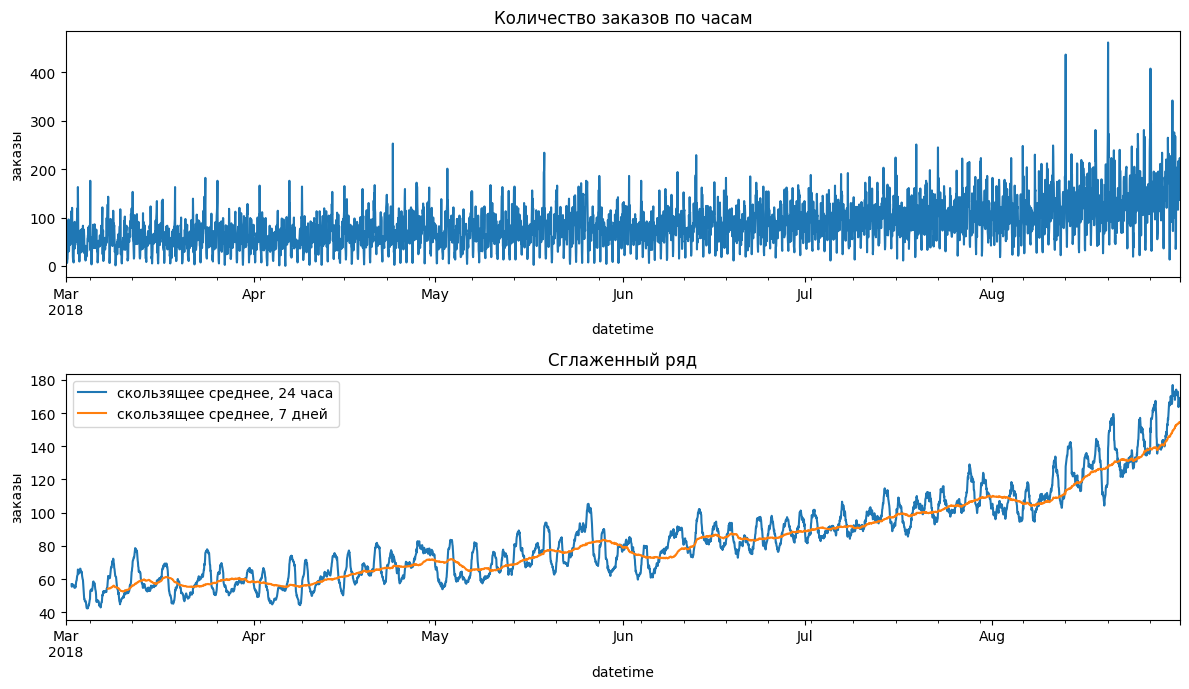

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7))
data['num_orders'].plot(ax=ax[0], title='Количество заказов по часам')
ax[0].set_ylabel('заказы')

data['num_orders'].rolling(24).mean().plot(ax=ax[1], label='скользящее среднее, 24 часа')
data['num_orders'].rolling(24 * 7).mean().plot(ax=ax[1], label='скользящее среднее, 7 дней')
ax[1].set_title('Сглаженный ряд')
ax[1].set_ylabel('заказы')
ax[1].legend()
plt.tight_layout()
plt.show()

Виден восходящий тренд: к концу периода средний уровень заказов заметно выше, чем в начале. На сглаженном ряде рост хорошо заметен и в дневном, и в недельном окне.

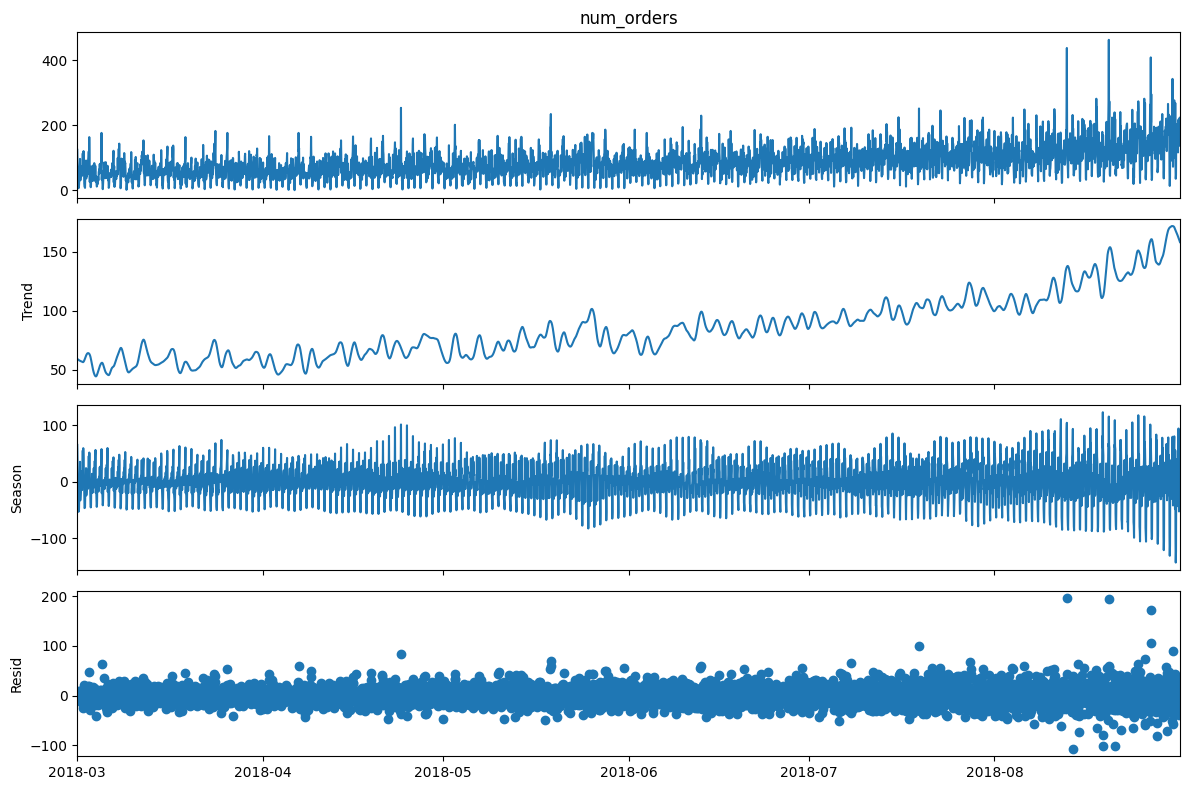

In [5]:
stl = STL(data['num_orders'], period=24).fit()
fig = stl.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

Суточная сезонность с периодом 24 выражена чётко: пик приходится на вечер и ночь. Амплитуда колебаний к концу периода растёт, остатки тоже становятся крупнее, поэтому на тестовой выборке модели будет сложнее.

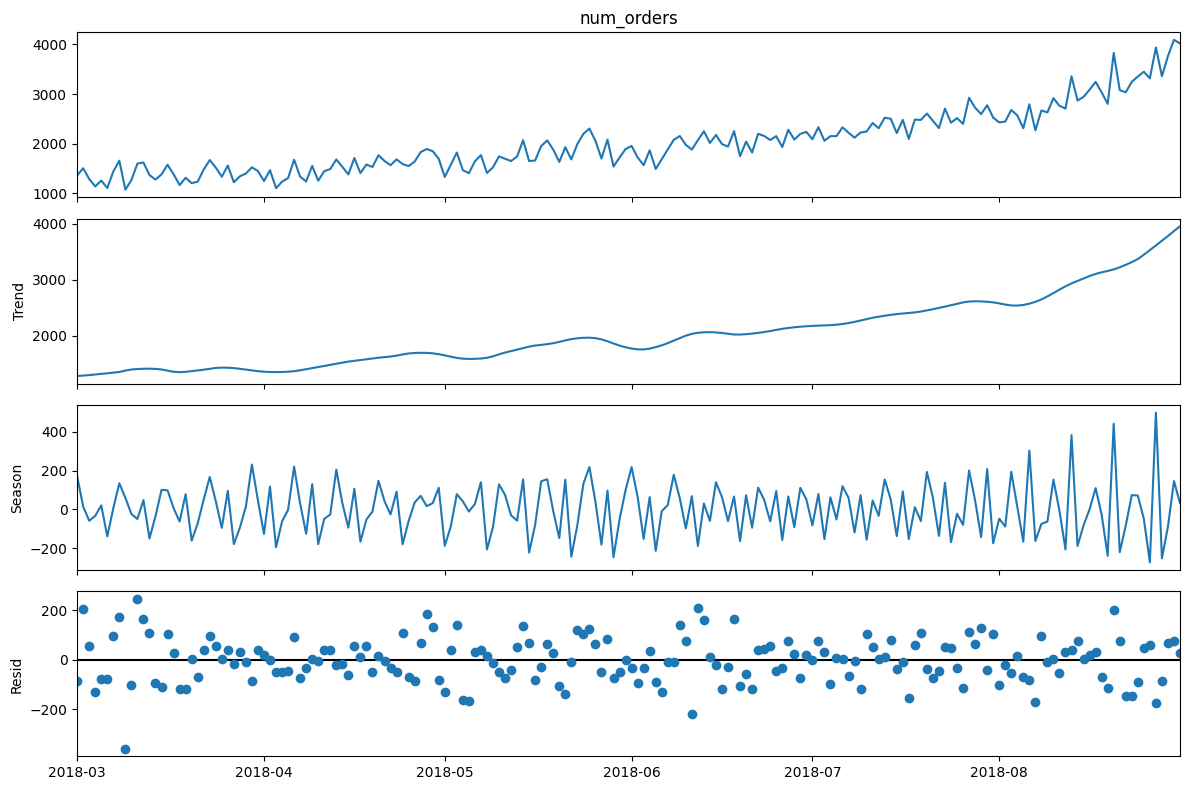

In [6]:
data_daily = data.resample('1D').sum()
stl_daily = STL(data_daily['num_orders'], period=7).fit()
fig = stl_daily.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

При ресемплинге по дням проявляется недельная сезонность с регулярными пиками. На часовых данных она маскируется и уходит в тренд декомпозиции, поэтому полезно рассмотреть ряд отдельно по дням.

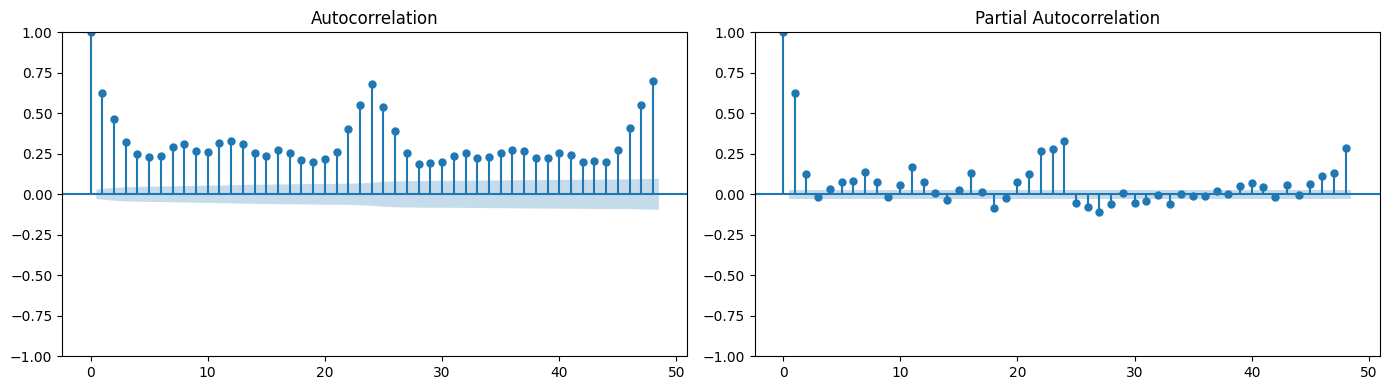

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(data['num_orders'], lags=48, ax=ax[0])
plot_pacf(data['num_orders'], lags=48, ax=ax[1], method='ywm')
plt.tight_layout()
plt.show()

На ACF и PACF чётко видны пики на лагах 1 и 24, что подтверждает суточную цикличность. Заметный пик ближе к лагу 48 говорит об устойчивых корреляциях на двое суток, а ранее обнаруженная недельная сезонность мотивирует добавить лаг 168.

In [8]:
adf_stat, p_value, *_ = adfuller(data['num_orders'])
print(f'ADF-статистика: {adf_stat:.4f}')
print(f'p-value: {p_value:.4f}')

ADF-статистика: -3.0689
p-value: 0.0289


Выводы:
- Виден восходящий тренд, к концу периода среднее количество заказов выросло примерно в полтора раза.
- STL подтверждает суточную сезонность с периодом 24, пик заказов приходится на вечер и ночь.
- На дневном ресемплинге проявляется недельная сезонность, на часовых данных она уходит в тренд декомпозиции.
- На ACF и PACF выделяются лаги 1 и 24, с учётом недельной сезонности в признаки имеет смысл брать лаги вплоть до 168.
- Тест Дики-Фуллера: p-value меньше 0.05, гипотеза о нестационарности отвергается.

## 3. Создание признаков

In [9]:
def make_features(df, max_lag, rolling_window):
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['day'] = df.index.day

    for lag in range(1, max_lag + 1):
        df[f'lag_{lag}'] = df['num_orders'].shift(lag)

    df['rolling_mean'] = df['num_orders'].shift(1).rolling(rolling_window).mean()
    return df

features = make_features(data, max_lag=168, rolling_window=24)
features = features.dropna()
print('Размер после dropna:', features.shape)
features.head()

Размер после dropna: (4248, 173)


/var/folders/3k/l29wzz5s1_xcfyh4fy9kgzsw0000gn/T/ipykernel_60873/1495161220.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag_{lag}'] = df['num_orders'].shift(lag)
/var/folders/3k/l29wzz5s1_xcfyh4fy9kgzsw0000gn/T/ipykernel_60873/1495161220.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag_{lag}'] = df['num_orders'].shift(lag)
/var/folders/3k/l29wzz5s1_xcfyh4fy9kgzsw0000gn/T/ipykernel_60873/1495161220.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inse

,num_orders,hour,dayofweek,day,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,...,lag_160,lag_161,lag_162,lag_163,lag_164,lag_165,lag_166,lag_167,lag_168,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-08 00:00:00,143,0,3,8,94.0,127.0,108.0,76.0,50.0,99.0,...,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,60.041667
2018-03-08 01:00:00,78,1,3,8,143.0,94.0,127.0,108.0,76.0,50.0,...,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,61.833333
2018-03-08 02:00:00,65,2,3,8,78.0,143.0,94.0,127.0,108.0,76.0,...,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,60.041667
2018-03-08 03:00:00,68,3,3,8,65.0,78.0,143.0,94.0,127.0,108.0,...,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,61.750000
2018-03-08 04:00:00,60,4,3,8,68.0,65.0,78.0,143.0,94.0,127.0,...,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,61.833333


## 4. Разбиение на выборки

In [10]:
target = features['num_orders']
features_x = features.drop('num_orders', axis=1)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    features_x, target, test_size=0.1, shuffle=False
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.1, shuffle=False
)

print('train :', X_train.shape, '| с', X_train.index.min(), 'по', X_train.index.max())
print('valid :', X_valid.shape, '| с', X_valid.index.min(), 'по', X_valid.index.max())
print('test  :', X_test.shape, '| с', X_test.index.min(), 'по', X_test.index.max())

train : (3440, 172) | с 2018-03-08 00:00:00 по 2018-07-29 07:00:00
valid : (383, 172) | с 2018-07-29 08:00:00 по 2018-08-14 06:00:00
test  : (425, 172) | с 2018-08-14 07:00:00 по 2018-08-31 23:00:00


Тест 10% от всех данных, валидация 10% от train. Хронологический порядок сохранён.

## 5. Обучение моделей

In [11]:
results = []

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

def evaluate(name, model, X_tr, y_tr, X_val, y_val):
    model.fit(X_tr, y_tr)
    score = rmse(y_val, model.predict(X_val))
    results.append((name, score))
    print(f'{name:55s} RMSE = {score:.3f}')

Бейзлайн: прогноз равен значению предыдущего часа.

In [12]:
baseline_pred = X_valid['lag_1']
baseline_score = rmse(y_valid, baseline_pred)
results.append(('Бейзлайн (предыдущий час)', baseline_score))
print(f'Бейзлайн RMSE = {baseline_score:.3f}')

Бейзлайн RMSE = 47.656


### Линейная регрессия

In [13]:
evaluate('LinearRegression', LinearRegression(), X_train, y_train, X_valid, y_valid)

LinearRegression                                        RMSE = 28.973


### Решающее дерево

In [14]:
for depth in [5, 10, 15, 20]:
    model = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)
    evaluate(f'DecisionTree (max_depth={depth})', model, X_train, y_train, X_valid, y_valid)

DecisionTree (max_depth=5)                              RMSE = 33.274


DecisionTree (max_depth=10)                             RMSE = 37.155


DecisionTree (max_depth=15)                             RMSE = 40.842


DecisionTree (max_depth=20)                             RMSE = 40.151


### Случайный лес

In [15]:
for n_est in [50, 100]:
    for depth in [10, 15]:
        model = RandomForestRegressor(
            n_estimators=n_est, max_depth=depth,
            random_state=RANDOM_STATE, n_jobs=-1
        )
        evaluate(
            f'RandomForest (n_estimators={n_est}, max_depth={depth})',
            model, X_train, y_train, X_valid, y_valid
        )

RandomForest (n_estimators=50, max_depth=10)            RMSE = 29.615


RandomForest (n_estimators=50, max_depth=15)            RMSE = 29.705


RandomForest (n_estimators=100, max_depth=10)           RMSE = 29.904


RandomForest (n_estimators=100, max_depth=15)           RMSE = 29.804


### Градиентный бустинг (LightGBM)

In [16]:
for lr in [0.05, 0.1]:
    for n_est in [100, 200]:
        for depth in [5, 10]:
            model = LGBMRegressor(
                learning_rate=lr, n_estimators=n_est, max_depth=depth,
                random_state=RANDOM_STATE, verbosity=-1
            )
            evaluate(
                f'LGBM (lr={lr}, n_est={n_est}, max_depth={depth})',
                model, X_train, y_train, X_valid, y_valid
            )

LGBM (lr=0.05, n_est=100, max_depth=5)                  RMSE = 29.514


LGBM (lr=0.05, n_est=100, max_depth=10)                 RMSE = 29.604


LGBM (lr=0.05, n_est=200, max_depth=5)                  RMSE = 29.349


LGBM (lr=0.05, n_est=200, max_depth=10)                 RMSE = 29.527


LGBM (lr=0.1, n_est=100, max_depth=5)                   RMSE = 29.588


LGBM (lr=0.1, n_est=100, max_depth=10)                  RMSE = 29.036


LGBM (lr=0.1, n_est=200, max_depth=5)                   RMSE = 29.801


LGBM (lr=0.1, n_est=200, max_depth=10)                  RMSE = 28.982


### Сравнение моделей

In [17]:
results_df = pd.DataFrame(results, columns=['model', 'rmse_valid']).sort_values('rmse_valid')
results_df.reset_index(drop=True, inplace=True)
results_df

,model,rmse_valid
0,LinearRegression,28.973018
1,"LGBM (lr=0.1, n_est=200, max_depth=10)",28.982066
2,"LGBM (lr=0.1, n_est=100, max_depth=10)",29.036368
3,"LGBM (lr=0.05, n_est=200, max_depth=5)",29.349274
4,"LGBM (lr=0.05, n_est=100, max_depth=5)",29.514278
5,"LGBM (lr=0.05, n_est=200, max_depth=10)",29.526506
6,"LGBM (lr=0.1, n_est=100, max_depth=5)",29.587614
7,"LGBM (lr=0.05, n_est=100, max_depth=10)",29.604170
8,"RandomForest (n_estimators=50, max_depth=10)",29.614630
9,"RandomForest (n_estimators=50, max_depth=15)",29.704933


## 6. Проверка на тестовой выборке

In [18]:
print('Топ-3 модели по валидации:')
print(results_df.head(3).to_string(index=False))

Топ-3 модели по валидации:
                                 model  rmse_valid
                      LinearRegression   28.973018
LGBM (lr=0.1, n_est=200, max_depth=10)   28.982066
LGBM (lr=0.1, n_est=100, max_depth=10)   29.036368


По валидации в лидерах идут LinearRegression и LightGBM, их RMSE отличаются в сотых долях. В качестве финальной модели берём LGBMRegressor с параметрами learning_rate=0.1, n_estimators=200, max_depth=10: он на уровне линейной регрессии по точности, при этом устойчивее к шуму и нелинейным эффектам и даёт удобную интерпретацию через важности признаков.

In [19]:
final_model = LGBMRegressor(
    learning_rate=0.1, n_estimators=200, max_depth=10,
    random_state=RANDOM_STATE, verbosity=-1
)
final_model.fit(X_train_full, y_train_full)

test_pred = final_model.predict(X_test)
test_rmse = rmse(y_test, test_pred)
print(f'RMSE на тесте = {test_rmse:.3f}')

RMSE на тесте = 36.734


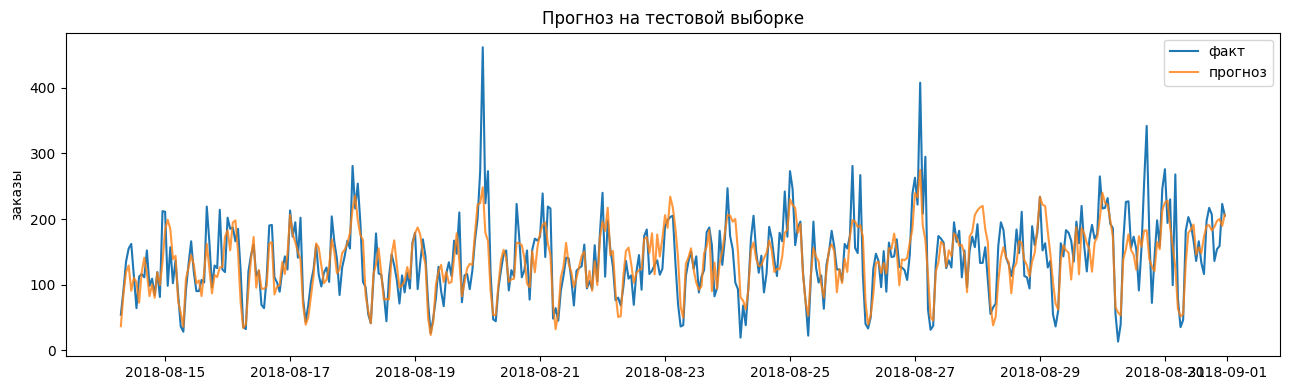

In [20]:
plt.figure(figsize=(13, 4))
plt.plot(y_test.index, y_test.values, label='факт')
plt.plot(y_test.index, test_pred, label='прогноз', alpha=0.8)
plt.title('Прогноз на тестовой выборке')
plt.ylabel('заказы')
plt.legend()
plt.tight_layout()
plt.show()

Прогноз повторяет общую динамику и суточную сезонность, но заметно сглаживает резкие пики. Это ожидаемое поведение бустинга на зашумлённом ряде с растущей амплитудой.

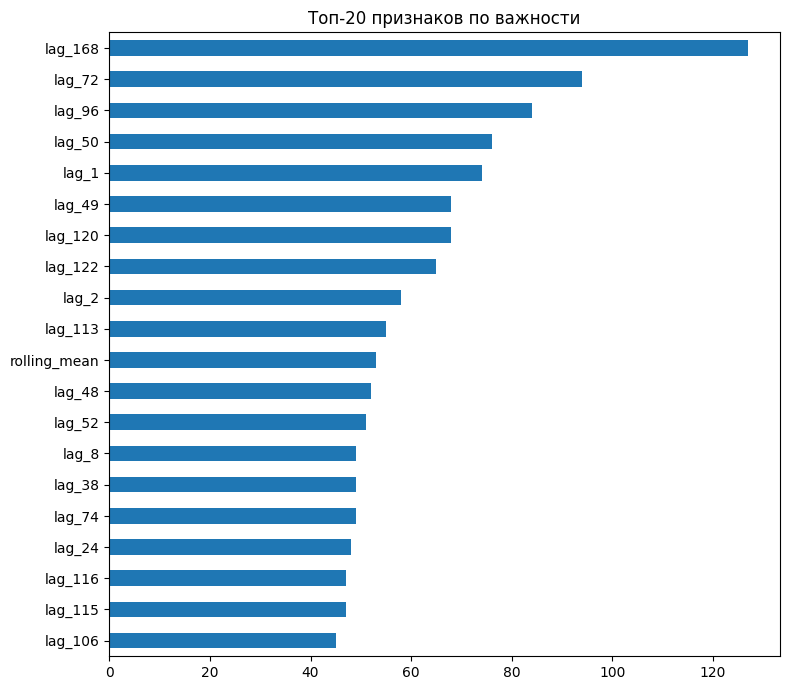

In [21]:
importances = pd.Series(final_model.feature_importances_, index=X_train_full.columns)
importances.nlargest(20).sort_values().plot(kind='barh', figsize=(8, 7), title='Топ-20 признаков по важности')
plt.tight_layout()
plt.show()

Самым важным признаком оказался недельный лаг 168, что подтверждает выявленную ранее недельную сезонность. Дальше идут многосуточные лаги (48, 72, 96, 120) и ближайший lag_1, скользящее среднее тоже среди значимых.

## 7. Выводы

- После ресемплинга по часу осталось 4416 наблюдений без пропусков. Ряд имеет восходящий тренд, ярко выраженную суточную сезонность и недельный цикл, заметный на ресемплинге по дням.
- В качестве признаков использованы календарные (hour, dayofweek, day), часовые лаги от 1 до 168 и скользящее среднее по 24 часам со сдвигом на 1.
- Сравнили четыре семейства моделей: LinearRegression, DecisionTree, RandomForest, LightGBM. На валидации лидируют LinearRegression и LightGBM с RMSE около 29.0, деревья и случайный лес отстают, бейзлайн заметно хуже.
- Финальная модель LGBMRegressor(learning_rate=0.1, n_estimators=200, max_depth=10), обученная на объединении train и valid, дала RMSE ≈ 36.7 на тесте. Требование RMSE ≤ 48 выполнено.
- Самым важным признаком для бустинга оказался недельный лаг 168. Далее идут многосуточные лаги и ближайший lag_1, что согласуется с выявленной суточной и недельной сезонностью.